# Eksperimen Model: SVM (Support Vector Machine)
SVM adalah algoritma *Machine Learning* klasik yang tangguh. Model ini sangat bergantung pada Normalisasi Data (StandardScaler) agar jarak antar dimensi dapat diukur dengan adil.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print('Library siap!')

Library siap!


### 1. Memuat Data MFCC 1D

In [2]:
try:
    X = np.load('X_features.npy')
    y = np.load('y_labels.npy')
    print(f'Data berhasil diload! Bentuk X: {X.shape}, Bentuk y: {y.shape}')
except FileNotFoundError:
    print('Error: File X_features.npy belum ada.')

Data berhasil diload! Bentuk X: (3150, 40), Bentuk y: (3150,)


### 2. Membagi dan Menormalisasi Data (StandardScaler)
SVM wajib dinormalisasi agar fitur yang nilainya sangat besar tidak mendominasi fitur yang nilainya kecil.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Jumlah data latih: {len(X_train)}')
print(f'Jumlah data uji: {len(X_test)}')

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Simpan scaler agar bisa dipakai saat prediksi (Inference) di Web
import os
os.makedirs('models', exist_ok=True)
joblib.dump(scaler, 'models/scaler_svm.pkl')
print('Scaler berhasil disimpan!')

Jumlah data latih: 2520
Jumlah data uji: 630
Scaler berhasil disimpan!


### 3. Melatih Model SVM

In [5]:
model_svm = SVC(kernel='rbf', C=10, gamma='scale', probability=True)
model_svm.fit(X_train_scaled, y_train)

print('Proses pelatihan (Training) selesai!')

Proses pelatihan (Training) selesai!


### 4. Laporan Evaluasi & Confusion Matrix


🎯 AKURASI SVM: 82.06%

              precision    recall  f1-score   support

       horas       0.82      0.84      0.83        90
  sampurasun       0.79      0.78      0.78        90
adilkatalino       0.79      0.76      0.77        90
      wawawa       0.90      0.84      0.87        90
   kulanuwun       0.81      0.92      0.86        90
       tabea       0.84      0.79      0.81        90
     peuhaba       0.80      0.81      0.81        90

    accuracy                           0.82       630
   macro avg       0.82      0.82      0.82       630
weighted avg       0.82      0.82      0.82       630



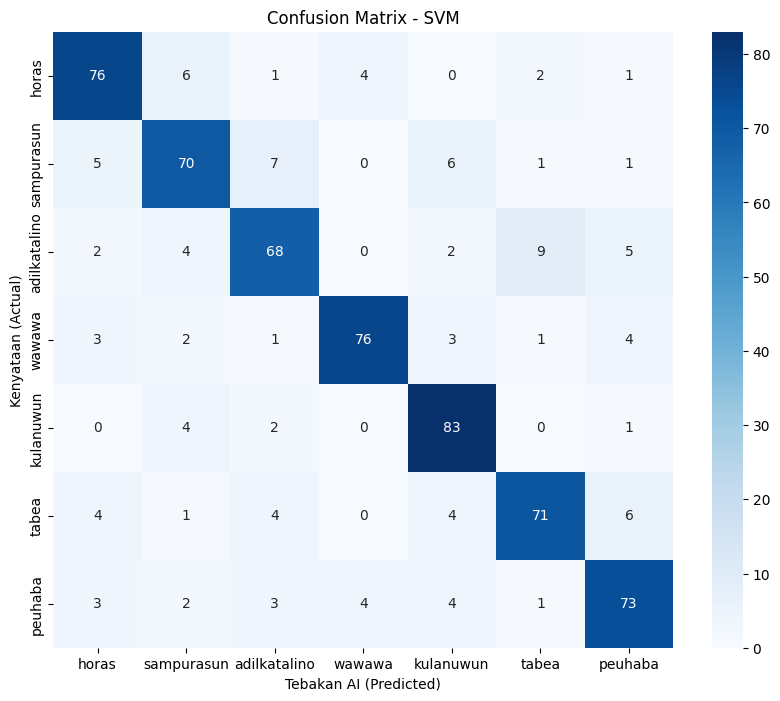

In [7]:
y_pred = model_svm.predict(X_test_scaled)
akurasi = accuracy_score(y_test, y_pred)
print(f'\n🎯 AKURASI SVM: {akurasi * 100:.2f}%\n')

classes = ['horas', 'sampurasun', 'adilkatalino', 'wawawa', 'kulanuwun', 'tabea', 'peuhaba']
print(classification_report(y_test, y_pred, target_names=classes))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix - SVM')
plt.xlabel('Tebakan AI (Predicted)')
plt.ylabel('Kenyataan (Actual)')
plt.show()

### 5. Simpan Model

In [ ]:
joblib.dump(model_svm, 'models/svm_model.pkl')
print('Model SVM berhasil disimpan di models/svm_model.pkl !')